✅ Connected to Neon Cloud | .env loaded from: .env
️ Looking for SQL in: c:\Users\USER\OneDrive\Documentos\GITHUB\PY_data_science\Projects\01_sales_analysis\Database
   📄 schema.sql exists: True
   📄 seeds.sql exists: True
   ✅ 'ventas' table created/recreated
   ✅ 6 rows successfully inserted into Neon

 6 rows ready for analysis


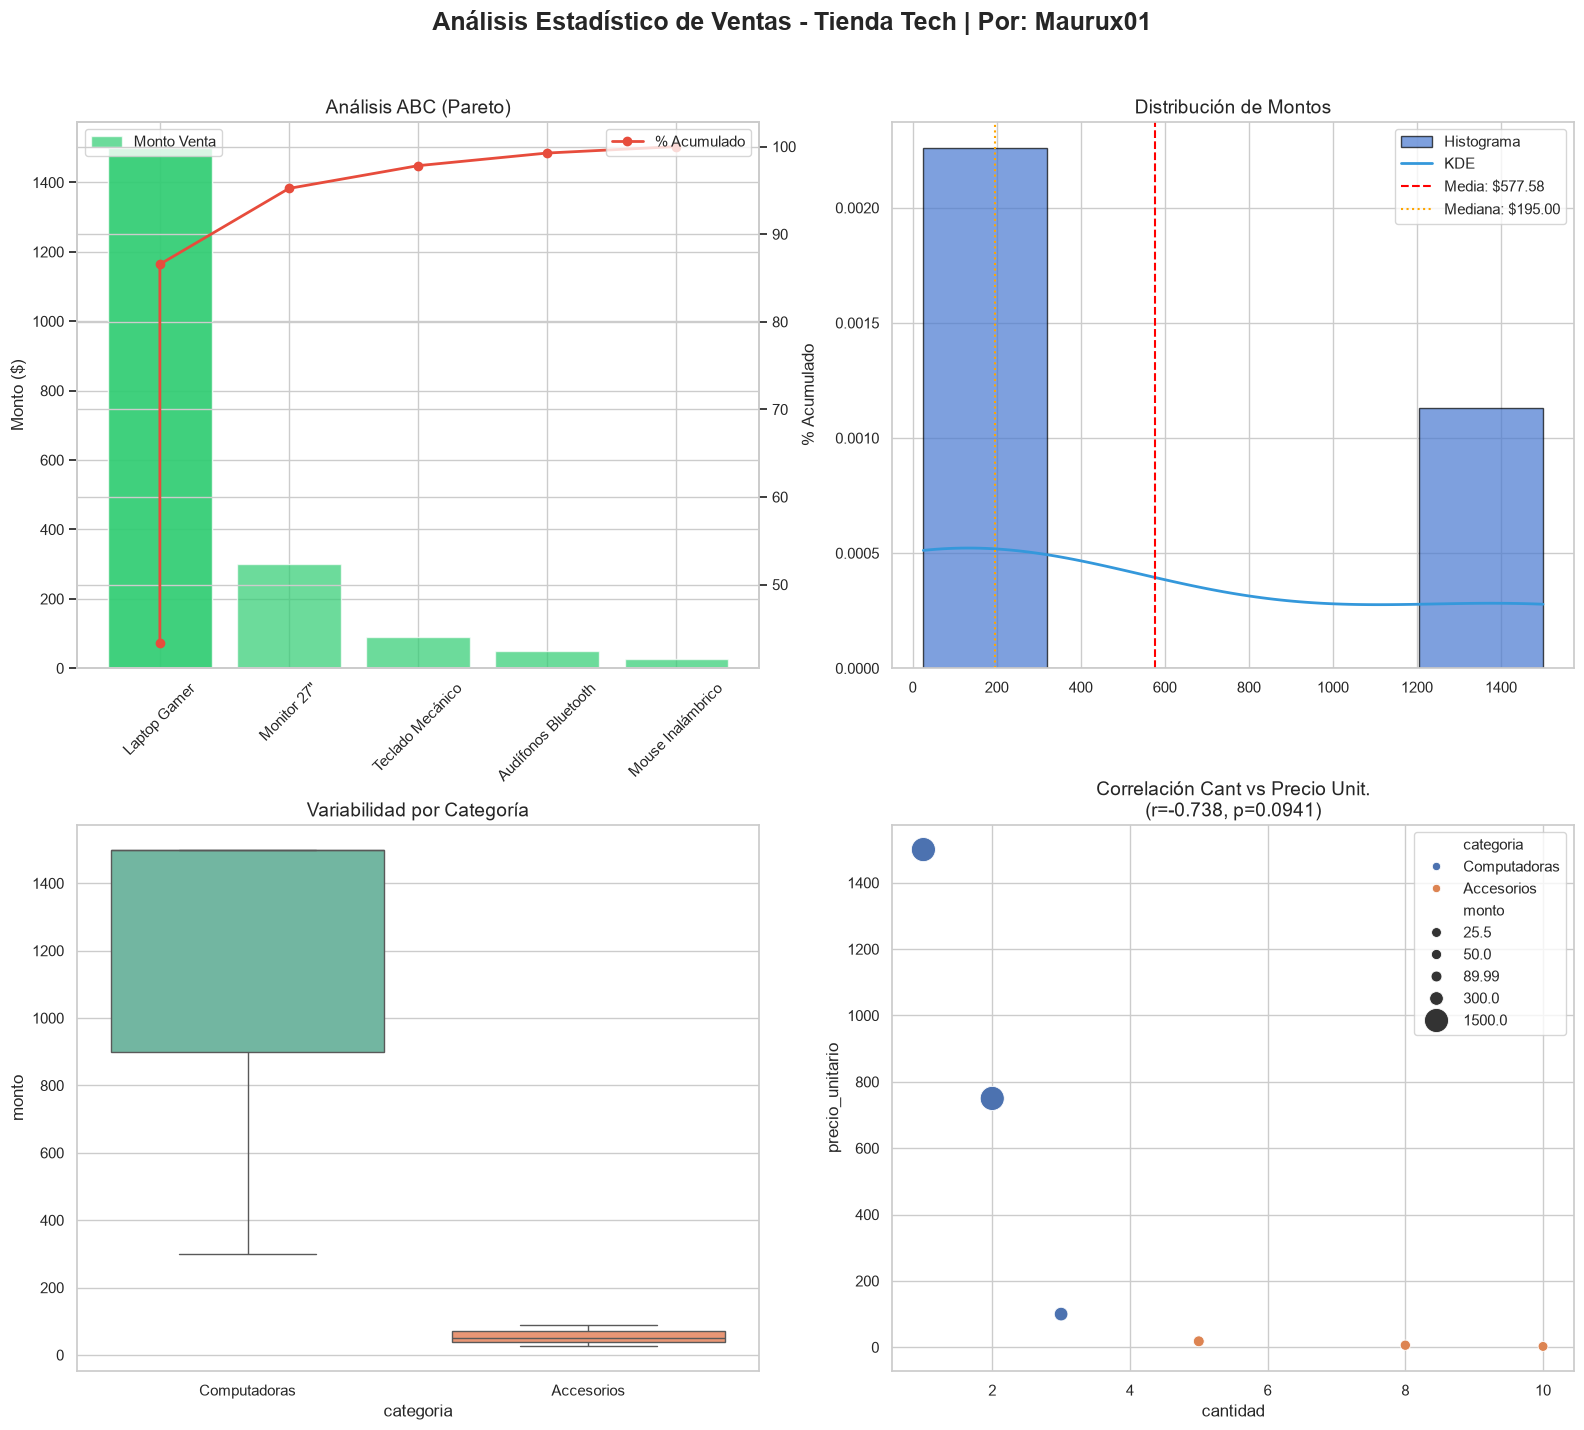


📊 Coefficient of Variation (CV): 124.8%
🏆 Top Product (Pareto A): Laptop Gamer ($1,500.00)


In [1]:
import numpy as np
from scipy import stats
from sqlalchemy import create_engine, text
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path

# ------------------------------------------------------------------
# 1. SECURE NEON CONNECTION
# ------------------------------------------------------------------
# Look for .env one level above the notebook (in PY_data_science)
notebook_dir = Path.cwd() 
# If we are in 01_sales_analysis, go one level up. If already at root, stay.
env_path = (notebook_dir / ".env") if (notebook_dir / ".env").exists() else (notebook_dir.parent / ".env")

load_dotenv(dotenv_path=env_path)

db_url = os.getenv("DATABASE_URL")
if not db_url:
    raise EnvironmentError(f" DATABASE_URL not found in {env_path}")

# Force psycopg v3
engine = create_engine(db_url.replace("postgresql://", "postgresql+psycopg://"))
print(f"✅ Connected to Neon Cloud | .env loaded from: {env_path.name}")

# ------------------------------------------------------------------
# 2. SCHEMA + SEEDS INJECTION (HARDENED ABSOLUTE PATHS)
# ------------------------------------------------------------------
# Build an absolute path from the notebook's current directory
# This avoids FileNotFoundError no matter where the kernel starts
base_dir = Path.cwd()
if base_dir.name == "01_sales_analysis":
    db_folder = base_dir / "Database"
else:
    # If the kernel started from the root, look inside 01_sales_analysis
    db_folder = base_dir / "01_sales_analysis" / "Database"

SCHEMA_FILE = db_folder / "schema.sql"
SEEDS_FILE = db_folder / "seeds.sql"

print(f"️ Looking for SQL in: {db_folder}")
print(f"   📄 schema.sql exists: {SCHEMA_FILE.exists()}")
print(f"   📄 seeds.sql exists: {SEEDS_FILE.exists()}")

if not SCHEMA_FILE.exists() or not SEEDS_FILE.exists():
    raise FileNotFoundError(f"❌ SQL files not found at: {db_folder}\nVerify they are in 01_sales_analysis/Database/")

try:
    with engine.connect() as conn:
        # Create table
        conn.execute(text(SCHEMA_FILE.read_text(encoding='utf-8')))
        print("   ✅ 'ventas' table created/recreated")
        
        # Insert data
        conn.execute(text(SEEDS_FILE.read_text(encoding='utf-8')))
        conn.commit()  # ¡OBLIGATORIO EN PSYCOPG V3!
        
        # Verify count
        count = conn.execute(text("SELECT COUNT(*) FROM ventas")).scalar()
        print(f"   ✅ {count} rows successfully inserted into Neon")
        
except Exception as e:
    print(f"❌ Migration error: {e}")
    raise

# ------------------------------------------------------------------
# 3. DATA LOADING AND STATISTICAL ANALYSIS
# ------------------------------------------------------------------
df = pd.read_sql("SELECT * FROM ventas", engine)
print(f"\n {len(df)} rows ready for analysis")

# Chart setup
sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Sales Statistical Analysis - Tech Store | By: Maurux01', 
             fontsize=18, fontweight='bold', y=1.02)

# CHART 1: PARETO (ABC)
df_sorted = df.sort_values('monto', ascending=False).reset_index(drop=True)
df_sorted['cumulative_pct'] = df_sorted['monto'].cumsum() / df_sorted['monto'].sum() * 100

axes[0, 0].bar(df_sorted['producto'], df_sorted['monto'], color='#2ecc71', alpha=0.7, label='Sale Amount')
ax2 = axes[0, 0].twinx()
ax2.plot(df_sorted['producto'], df_sorted['cumulative_pct'], color='#e74c3c', marker='o', linewidth=2, label='% Cumulative')
axes[0, 0].set_title('ABC (Pareto) Analysis', fontsize=14)
axes[0, 0].set_ylabel('Amount ($)')
ax2.set_ylabel('% Cumulative')
axes[0, 0].legend(loc='upper left')
ax2.legend(loc='upper right')
axes[0, 0].tick_params(axis='x', rotation=45)

# CHART 2: DISTRIBUTION + KDE
axes[0, 1].hist(df['monto'], bins=5, edgecolor='black', alpha=0.7, density=True, label='Histogram')
kde = stats.gaussian_kde(df['monto'])
x_range = np.linspace(df['monto'].min(), df['monto'].max(), 100)
axes[0, 1].plot(x_range, kde(x_range), color='#3498db', linewidth=2, label='KDE')
axes[0, 1].axvline(df['monto'].mean(), color='red', linestyle='--', label=f'Media: ${df["monto"].mean():.2f}')
axes[0, 1].axvline(df['monto'].median(), color='orange', linestyle=':', label=f'Mediana: ${df["monto"].median():.2f}')
axes[0, 1].set_title('Amount Distribution', fontsize=14)
axes[0, 1].legend()

# CHART 3: BOXPLOT BY CATEGORY
sns.boxplot(data=df, x='categoria', y='monto', hue='categoria', 
            ax=axes[1, 0], palette='Set2', legend=False)
axes[1, 0].set_title('Variability by Category', fontsize=14)

# CHART 4: CORRELATION
df['precio_unitario'] = df['monto'] / df['cantidad']
corr_coef, p_value = stats.pearsonr(df['cantidad'], df['precio_unitario'])
sns.scatterplot(data=df, x='cantidad', y='precio_unitario', size='monto', sizes=(50, 300), 
                hue='categoria', ax=axes[1, 1], palette='deep')
axes[1, 1].set_title(f'Qty vs Unit Price Correlation\n(r={corr_coef:.3f}, p={p_value:.4f})', fontsize=14)

plt.tight_layout()
plt.show()

# STATISTICAL SUMMARY
print(f"\n📊 Coefficient of Variation (CV): {(df['monto'].std()/df['monto'].mean()*100):.1f}%")
print(f"🏆 Top Product (Pareto A): {df_sorted.iloc[0]['producto']} (${df_sorted.iloc[0]['monto']:,.2f})")